# Modeling

## Setup

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, classification_report

In [1]:
!pip install -q scikit-learn-intelex
from sklearnex import patch_sklearn
patch_sklearn()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.3/111.3 MB 8.7 MB/s eta 0:00:00


Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


## Load Data

In [2]:
from google.colab import files
uploaded = files.upload()

Saving test.csv to test.csv
Saving train.csv to train.csv


In [3]:
import pandas as pd

train = pd.read_csv("train.csv")
test = pd.read_csv("train.csv")


## Prepare cols

In [4]:
X_train, y_train = train.drop("Survived", axis=1), train["Survived"]
X_test, y_test = test.drop("Survived", axis=1), test["Survived"]

In [6]:
cat_features = ["Title", "Pclass", "Sex", "Age_missing", "Age_bin", "FamilyGroup",
            "TicketPrefix", "Deck", "Embarked", "Cabin_missing"]
num_features = ["FamilySize", "Fare_log"] # "Age"

## Utils

In [53]:
!pip install -q scikit-learn-intelex
from sklearnex import patch_sklearn
patch_sklearn()

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


In [44]:
# Plot confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def display_confusion_matrix(y, y_pred, labels, title):
  cm = confusion_matrix(y, y_pred)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                display_labels=labels)

  plt.figure(figsize=(5,4))
  disp.plot(cmap="Blues", values_format="d")
  plt.title(title)
  plt.show()

In [73]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
import matplotlib.pyplot as plt

def perform_stratified_cross_val(model, X, y, score="accuracy", n_splits=5):
  cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

  # 1) CV accuracy
  scores = cross_val_score(model, X, y, cv=cv, scoring=score, n_jobs=-1)
  print(f"CV {score}: {scores.mean():.3f} ± {scores.std():.3f}")

  # 2) Out-of-fold predictions for diagnostics
  y_pred_oof = cross_val_predict(model, X, y, cv=cv, method="predict")

  cm = confusion_matrix(y, y_pred_oof)
  disp = ConfusionMatrixDisplay(cm, display_labels=["Died (0)", "Survived (1)"])
  disp.plot(cmap="Blues", values_format="d")
  plt.title("Confusion Matrix (OOF)"); plt.show()

  # (Optional) ROC-AUC with OOF probabilities
  y_proba_oof = cross_val_predict(model, X, y, cv=cv, method="predict_proba")[:, 1]
  print(f"CV ROC-AUC: {roc_auc_score(y, y_proba_oof):.3f}")

  return scores

## Build preprocessing pipeline

In [9]:
num_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", num_transformer, num_features),
    ("cat", cat_transformer, cat_features)
])

## Models Analysis

### Logistic Regression

CV accuracy: 0.824 ± 0.034


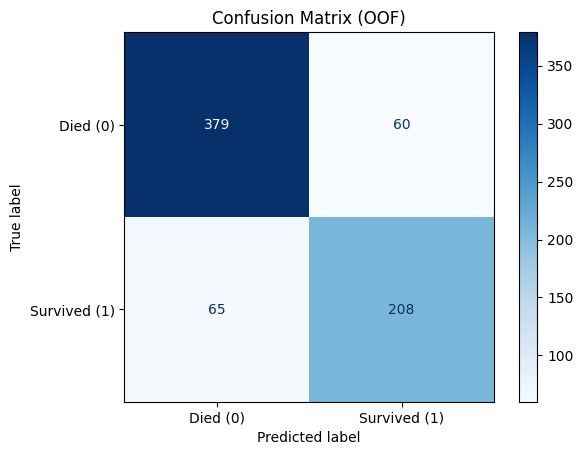

CV ROC-AUC: 0.880


In [51]:
from sklearn.linear_model import LogisticRegression
lr_model = Pipeline([
    ("prep", preprocess),
    ("lr", LogisticRegression(max_iter=1000))
])
perform_stratified_cross_val(lr_model, X_train, y_train)

In [45]:
lr_model.fit(X_train, y_train)
y_pred_test = lr_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_test)
print(accuracy)
print(classification_report(y_test, y_pred_test))

0.8412921348314607
              precision    recall  f1-score   support

           0       0.86      0.89      0.87       439
           1       0.81      0.77      0.79       273

    accuracy                           0.84       712
   macro avg       0.83      0.83      0.83       712
weighted avg       0.84      0.84      0.84       712



<Figure size 500x400 with 0 Axes>

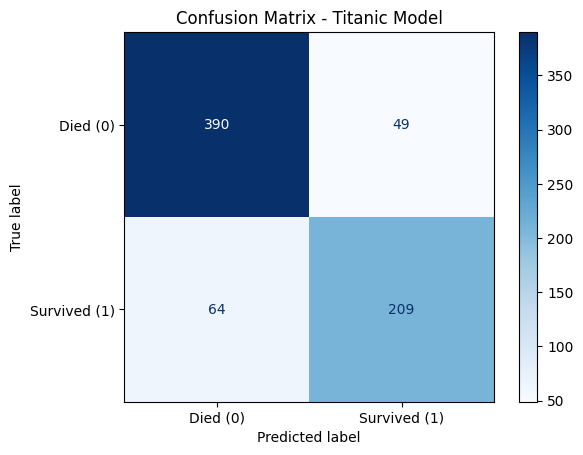

In [46]:
display_confusion_matrix(y_test, y_pred_test,
 ["Died (0)", "Survived (1)"], "Confusion Matrix - Titanic Model")


### Logistic regression with polynomial features

In [68]:
from sklearn.preprocessing import PolynomialFeatures

poly_preprocess = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=2, include_bias=False))
    ]), num_features),
    ("cat", cat_transformer, cat_features)
])

CV accuracy: 0.829 ± 0.027


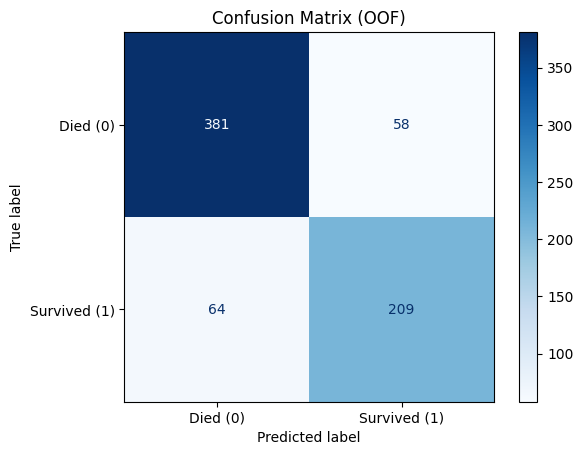

CV ROC-AUC: 0.880


In [69]:
lr_model = Pipeline([
    ("prep", poly_preprocess),
    ("lr", LogisticRegression(max_iter=1000))
])
perform_stratified_cross_val(lr_model, X_train, y_train)

In [70]:
lr_model.fit(X_train, y_train)
y_pred_test = lr_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_test)
print(accuracy)
print(classification_report(y_test, y_pred_test))

0.8441011235955056
              precision    recall  f1-score   support

           0       0.86      0.89      0.88       439
           1       0.81      0.78      0.79       273

    accuracy                           0.84       712
   macro avg       0.84      0.83      0.83       712
weighted avg       0.84      0.84      0.84       712



### Random forest

CV accuracy: 0.812 ± 0.018


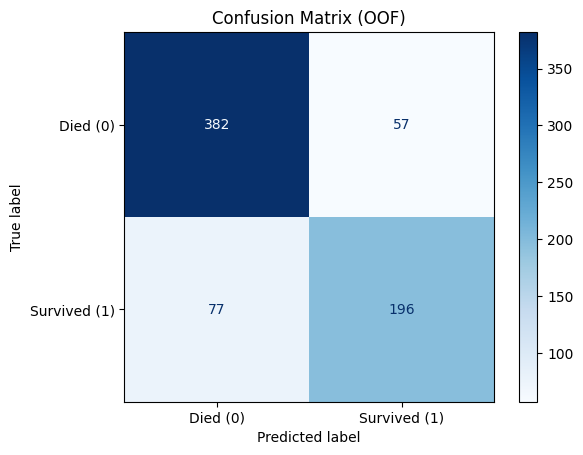

CV ROC-AUC: 0.856


In [77]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("prep", preprocess),
    ("rf", RandomForestClassifier(n_estimators=300, random_state=42))
])
forest_scores = perform_stratified_cross_val(rf_model, X_train, y_train)


In [54]:
rf_model.fit(X_train, y_train)
y_pred_test = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_test)
print(accuracy)
print(classification_report(y_test, y_pred_test))

0.9620786516853933
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       439
           1       0.97      0.93      0.95       273

    accuracy                           0.96       712
   macro avg       0.96      0.96      0.96       712
weighted avg       0.96      0.96      0.96       712



### SVC


CV accuracy: 0.831 ± 0.021


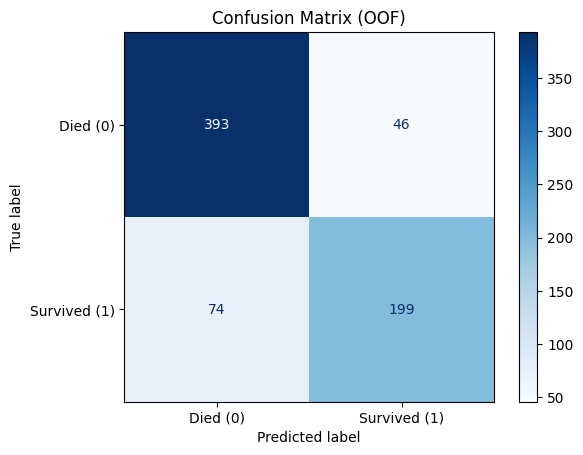

AttributeError: This 'Pipeline' has no attribute 'predict_proba'

In [82]:
from sklearn.svm import SVC

svc_model = Pipeline([
    ("prep", preprocess),
    ("svc", SVC(gamma="auto"))
])
svm_scores = perform_stratified_cross_val(svc_model, X_train, y_train)

In [80]:
forest_scores

array([0.83216783, 0.79020979, 0.78873239, 0.82394366, 0.82394366])

In [81]:
svm_scores

array([0.83216783, 0.79020979, 0.78873239, 0.82394366, 0.82394366])

ValueError: x and y must have same first dimension, but have shapes (10,) and (5,)

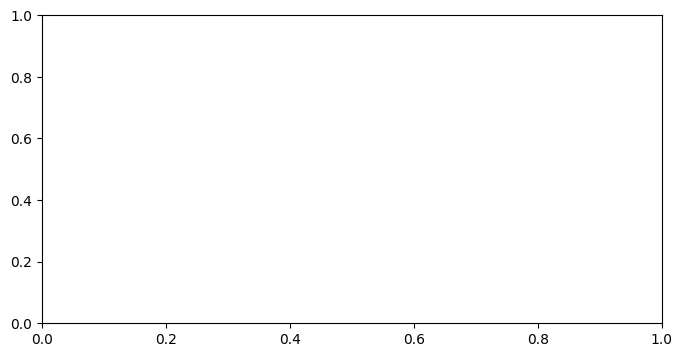

In [78]:
plt.figure(figsize=(8, 4))
plt.plot([1]*10, svm_scores, ".")
plt.plot([2]*10, forest_scores, ".")
plt.boxplot([svm_scores, forest_scores], labels=("SVM", "Random Forest"))
plt.ylabel("Accuracy")
plt.show()

In [72]:
svc_model.fit(X_train, y_train)
y_pred_test = svc_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_test)
print(accuracy)

0.8314606741573034


### XGBoost

CV accuracy: 0.844 ± 0.026


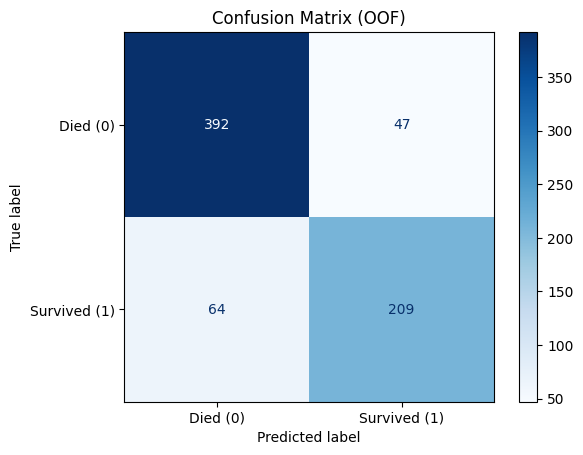

CV ROC-AUC: 0.890


In [56]:
from xgboost import XGBClassifier

xgb_model = Pipeline([
    ("prep", preprocess),
    ("xgb", XGBClassifier(n_estimators=300, learning_rate=0.05,
                          max_depth=4, random_state=42))
])
perform_stratified_cross_val(xgb_model, X_train, y_train)


In [59]:
xgb_model.fit(X_train, y_train)
y_pred_test = xgb_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_test)
print(accuracy)
print(classification_report(y_test, y_pred_test))

0.9241573033707865
              precision    recall  f1-score   support

           0       0.92      0.95      0.94       439
           1       0.92      0.88      0.90       273

    accuracy                           0.92       712
   macro avg       0.92      0.91      0.92       712
weighted avg       0.92      0.92      0.92       712



### LightGBM

CV accuracy: 0.827 ± 0.028
[LightGBM] [Info] Number of positive: 218, number of negative: 351
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000271 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 178
[LightGBM] [Info] Number of data points in the train set: 569, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383128 -> initscore=-0.476291
[LightGBM] [Info] Start training from score -0.476291
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with pos

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 219, number of negative: 351
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000238 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 179
[LightGBM] [Info] Number of data points in the train set: 570, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.384211 -> initscore=-0.471714
[LightGBM] [Info] Start training from score -0.471714
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 219, number of negative: 351
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000257 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 180
[LightGBM] [Info] Number of data points in the train set: 570, number of used features: 34
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.384211 -> initscore=-0.471714
[LightGBM] [Info] Start training from score -0.471714
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


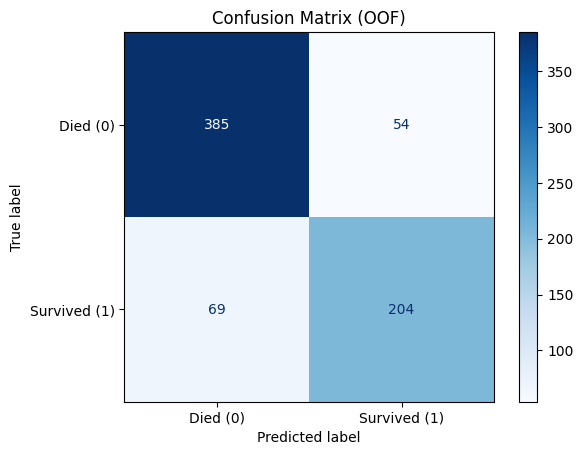

[LightGBM] [Info] Number of positive: 218, number of negative: 351
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000226 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 178
[LightGBM] [Info] Number of data points in the train set: 569, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383128 -> initscore=-0.476291
[LightGBM] [Info] Start training from score -0.476291
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 218, number of negative: 352
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000212 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 178
[LightGBM] [Info] Number of data points in the train set: 570, number of used features: 34
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.382456 -> initscore=-0.479136
[LightGBM] [Info] Start training from score -0.479136
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [60]:
from lightgbm import LGBMClassifier

lgb_model = Pipeline([
    ("prep", preprocess),
    ("lgb", LGBMClassifier(n_estimators=300, learning_rate=0.05,
                           max_depth=-1, random_state=42))
])
perform_stratified_cross_val(lgb_model, X_train, y_train)


In [61]:
lgb_model.fit(X_train, y_train)
y_pred_test = lgb_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_test)
print(accuracy)
print(classification_report(y_test, y_pred_test))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 273, number of negative: 439
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000284 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 199
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383427 -> initscore=-0.475028
[LightGBM] [Info] Start training from score -0.475028
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf